In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('food_delivery_orders.csv', parse_dates=['order_date'])
df.head()

,order_date,city,restaurant_category,cuisine,order_value,discount_percent,delivery_time_min,rating,profit_per_order
0,2023-01-01,Karachi,Fine Dining,Continental,2768.0,25.0,36.2,4.5,95.0
1,2023-01-01,Karachi,Fine Dining,Steakhouse,4979.0,44.8,23.3,4.8,-437.0
2,2023-01-01,Karachi,Cloud Kitchen,Indian,4008.0,11.9,39.6,4.2,618.0
3,2023-01-01,Islamabad,Fine Dining,Steakhouse,3260.0,8.3,35.8,4.5,423.0
4,2023-01-01,Karachi,Fast Food,Pizza,435.0,13.5,29.4,4.8,53.0


In [ ]:
# TASK 1

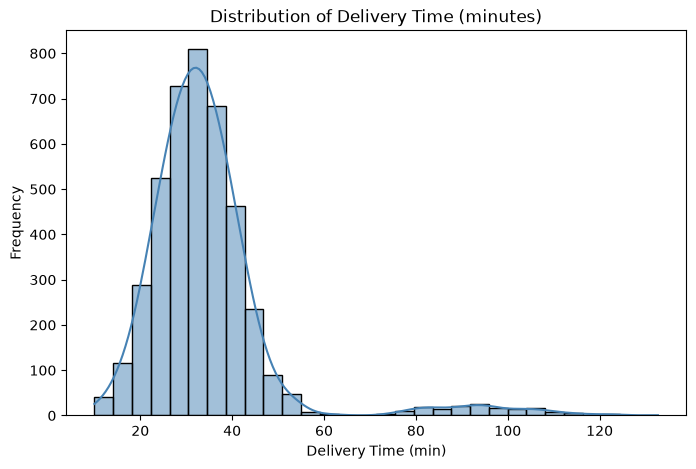

Skewness: 2.88
Mean: 34.54 min
Median: 32.50 min


In [2]:
col = 'delivery_time_min'

plt.figure(figsize=(8,5))
sns.histplot(df[col], kde=True, bins=30, color='steelblue')
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.show()

skew = df[col].skew()
mean_val = df[col].mean()
median_val = df[col].median()

print(f"Skewness: {skew:.2f}")
print(f"Mean: {mean_val:.2f} min")
print(f"Median: {median_val:.2f} min")

In [ ]:
# Since the data is skewed, median is the more honest number to advertise.

In [ ]:
# TASK 2

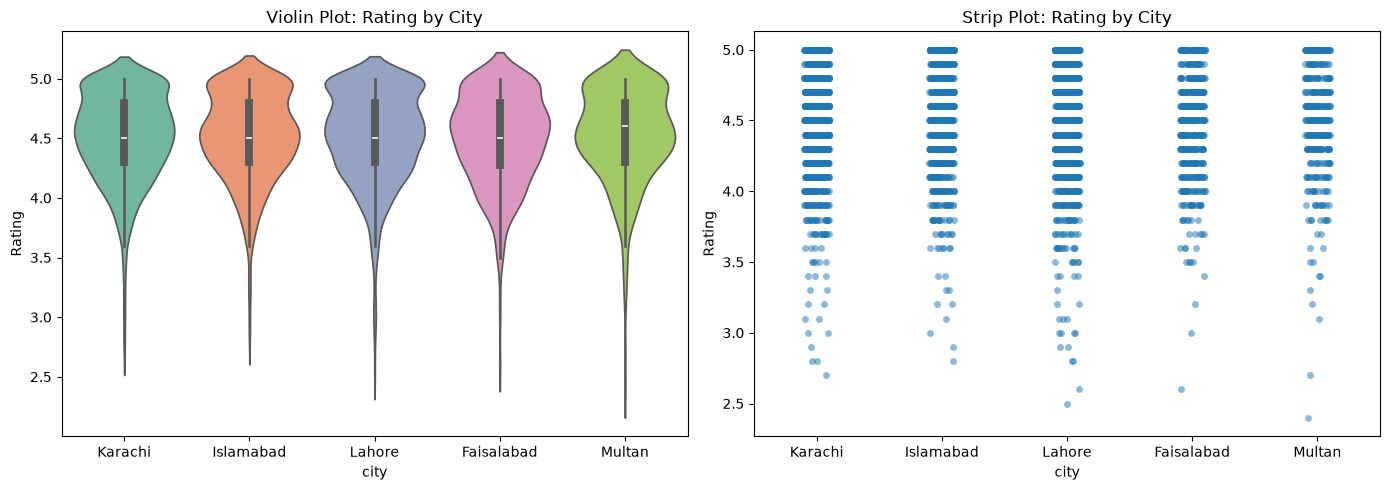

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Violin plot
sns.violinplot(data=df, x='city', y='rating', ax=axes[0], palette='Set2')
axes[0].set_title('Violin Plot: Rating by City')
axes[0].set_ylabel('Rating')

# Strip plot with jitter
sns.stripplot(data=df, x='city', y='rating', ax=axes[1], jitter=True, alpha=0.5)
axes[1].set_title('Strip Plot: Rating by City')
axes[1].set_ylabel('Rating')

plt.tight_layout()
plt.show()

In [ ]:
# Multan has the most inconsistent rating as its highly spread between large range of below 2.5 to 5.0.

In [4]:
# TASK 3

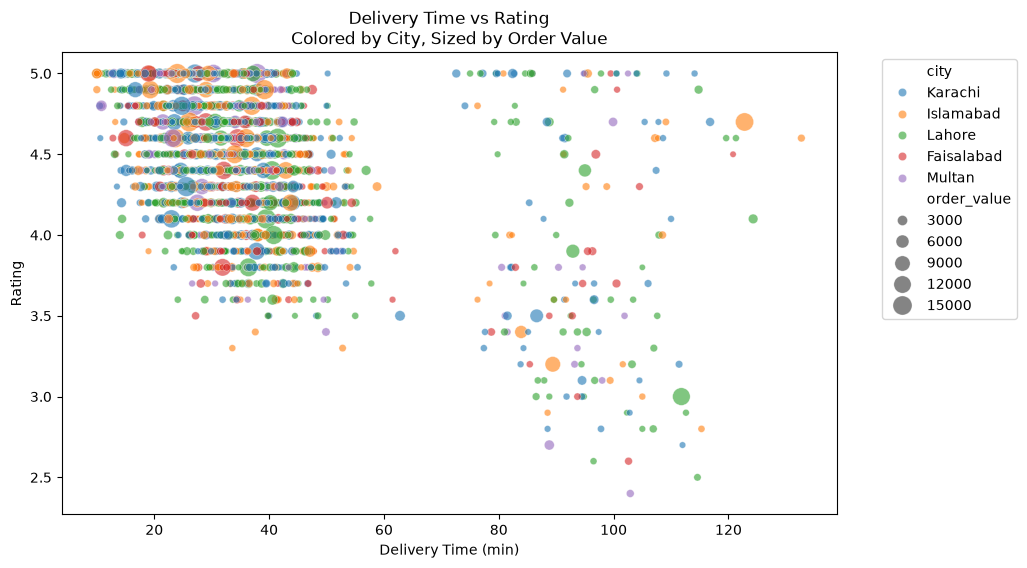

In [5]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='delivery_time_min', y='rating', hue='city', 
                size='order_value', sizes=(20, 200), alpha=0.6)
plt.title('Delivery Time vs Rating\nColored by City, Sized by Order Value')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Rating')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [23]:
# One thing is clear. Worse rating are in those orders whose delivery time exceeds 60m. There is no evidence that rating is good on large
# sized orders.

In [6]:
# TASK 4

In [7]:
numeric_cols = ['order_value', 'discount_percent', 'delivery_time_min', 'rating', 'profit_per_order']
corr_pearson = df[numeric_cols].corr(method='pearson')
corr_spearman = df[numeric_cols].corr(method='spearman')

# Find pair with largest absolute difference
diff = (corr_pearson - corr_spearman).abs().unstack()
diff = diff[diff < 1]  # remove diagonal
largest_diff_pair = diff.idxmax()
print(f"Largest disagreement: {largest_diff_pair}")
print(f"Pearson: {corr_pearson.loc[largest_diff_pair[0], largest_diff_pair[1]]:.3f}")
print(f"Spearman: {corr_spearman.loc[largest_diff_pair[0], largest_diff_pair[1]]:.3f}")
print(f"Difference: {diff.max():.3f}")

Largest disagreement: ('discount_percent', 'profit_per_order')
Pearson: -0.082
Spearman: -0.381
Difference: 0.299


In [8]:
# TASK 5

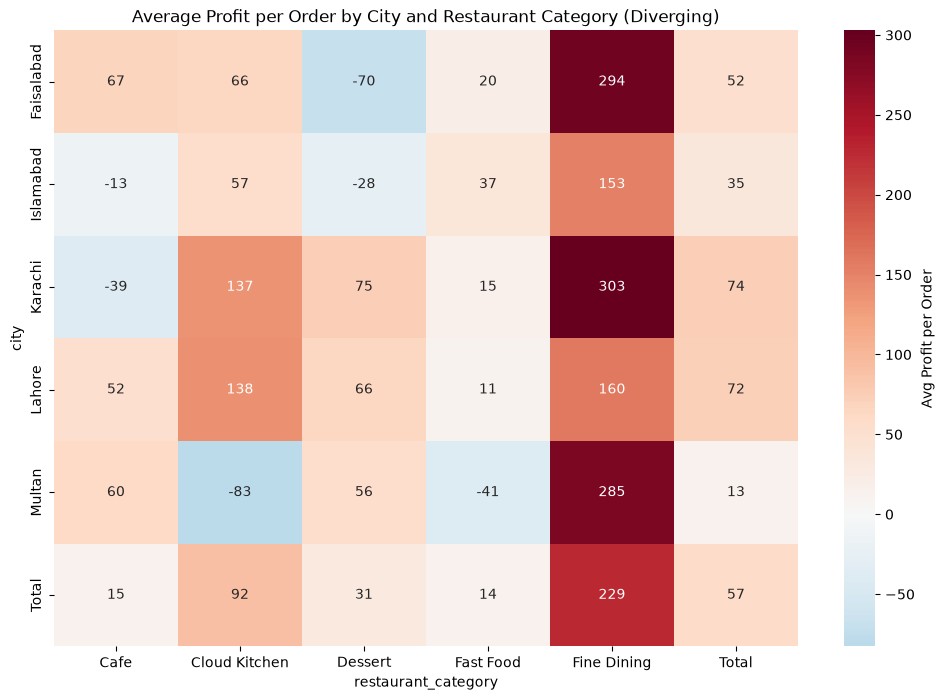

Most profitable combination: Karachi - Fine Dining with avg profit 303
Top revenue combination: Lahore - Cloud Kitchen with total revenue 449767


In [9]:
pivot = pd.pivot_table(df, index='city', columns='restaurant_category', 
                       values='profit_per_order', aggfunc='mean', margins=True, margins_name='Total')

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdBu_r', center=0, cbar_kws={'label': 'Avg Profit per Order'})
plt.title('Average Profit per Order by City and Restaurant Category (Diverging)')
plt.show()

# Find cell with max average profit (excluding Total)
max_profit = pivot.loc[pivot.index != 'Total', pivot.columns != 'Total'].stack().idxmax()
print(f"Most profitable combination: {max_profit[0]} - {max_profit[1]} with avg profit {pivot.loc[max_profit]:.0f}")

# Also check total revenue by same combination for comparison
revenue_pivot = pd.pivot_table(df, index='city', columns='restaurant_category', 
                               values='order_value', aggfunc='sum', margins=True, margins_name='Total')
top_revenue = revenue_pivot.loc[revenue_pivot.index != 'Total', revenue_pivot.columns != 'Total'].stack().idxmax()
print(f"Top revenue combination: {top_revenue[0]} - {top_revenue[1]} with total revenue {revenue_pivot.loc[top_revenue]:.0f}")

In [10]:
# TASK 6

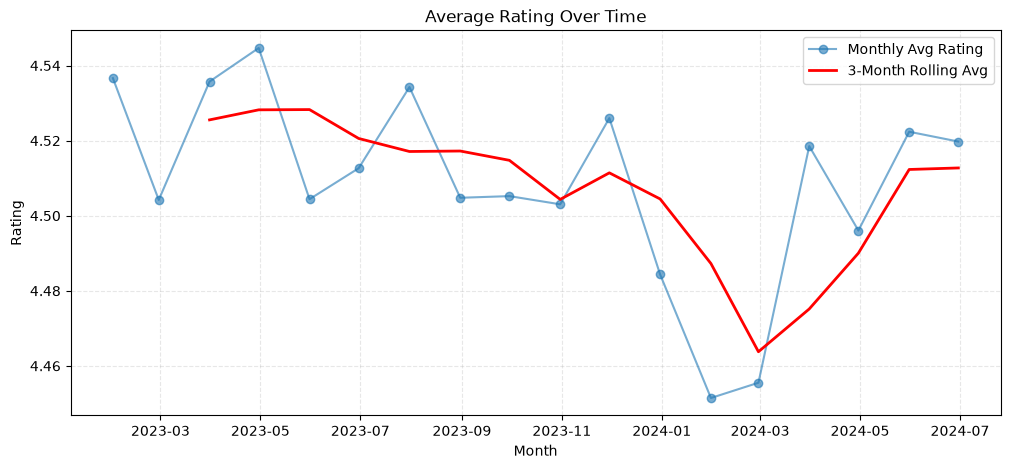

In [12]:
df_monthly = df.set_index('order_date').resample('ME')['rating'].mean()
rolling_3 = df_monthly.rolling(window=3).mean()

plt.figure(figsize=(12,5))
plt.plot(df_monthly.index, df_monthly.values, marker='o', label='Monthly Avg Rating', alpha=0.6)
plt.plot(rolling_3.index, rolling_3.values, color='red', linewidth=2, label='3‑Month Rolling Avg')
plt.title('Average Rating Over Time')
plt.xlabel('Month')
plt.ylabel('Rating')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

In [13]:
# TASK 7

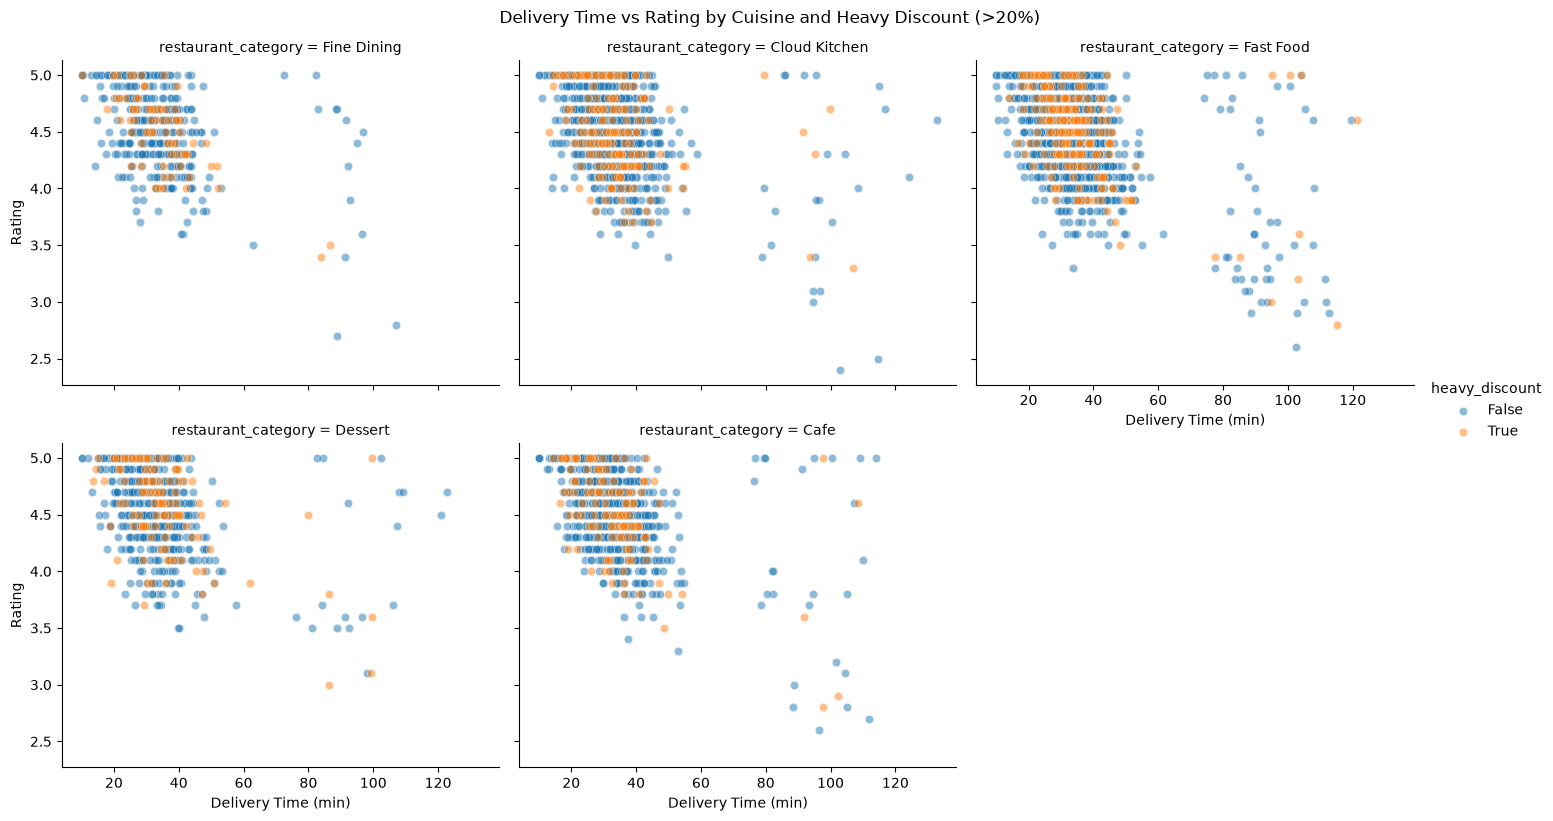

In [14]:
df['heavy_discount'] = df['discount_percent'] > 20

g = sns.FacetGrid(df, col='restaurant_category', hue='heavy_discount', 
                  height=4, aspect=1.2, col_wrap=3)
g.map(sns.scatterplot, 'delivery_time_min', 'rating', alpha=0.5)
g.add_legend()
g.set_axis_labels('Delivery Time (min)', 'Rating')
g.fig.suptitle('Delivery Time vs Rating by Cuisine and Heavy Discount (>20%)', y=1.02)
plt.show()

In [15]:
# TASK 8

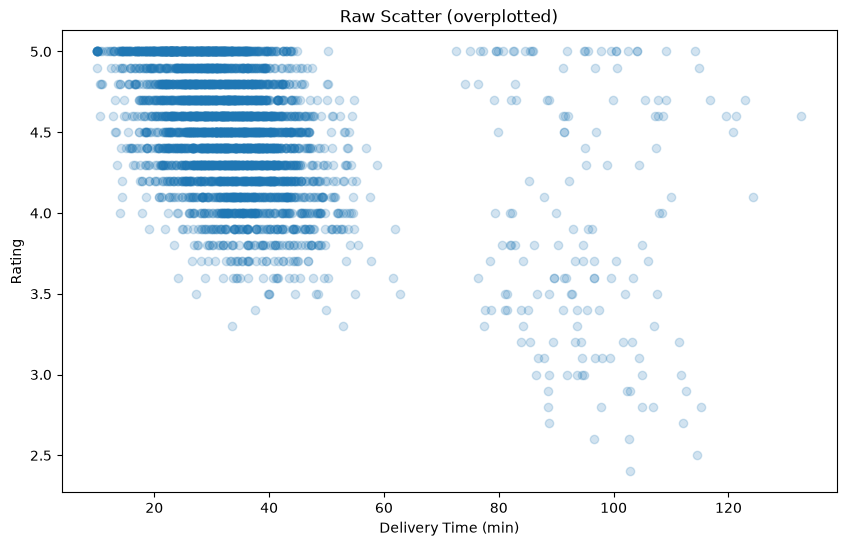

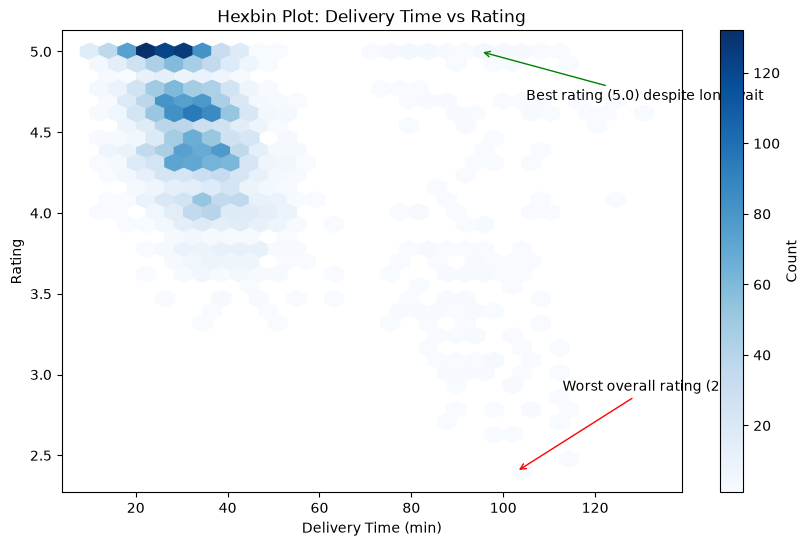

In [24]:
# Raw scatter (overplotted)
plt.figure(figsize=(10,6))
plt.scatter(df['delivery_time_min'], df['rating'], alpha=0.2)
plt.title('Raw Scatter (overplotted)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Rating')
plt.show()

# Fixed plot using hexbin (since we have many overlapping points)
# ---------- Task 8 (fixed) ----------

# Overplotting fix: hexbin
plt.figure(figsize=(10,6))
hb = plt.hexbin(df['delivery_time_min'], df['rating'], gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(hb, label='Count')
plt.title('Hexbin Plot: Delivery Time vs Rating')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Rating')

# ---- Annotations ----

# Find best rating despite long delivery (> 90 min)
candidate_long = df[(df['rating'] == df['rating'].max()) & (df['delivery_time_min'] > 90)]
if not candidate_long.empty:
    best_long = candidate_long.iloc[0]
    plt.annotate(f'Best rating ({best_long["rating"]:.1f}) despite long wait',
                 xy=(best_long['delivery_time_min'], best_long['rating']),
                 xytext=(best_long['delivery_time_min']+10, best_long['rating']-0.3),
                 arrowprops=dict(arrowstyle='->', color='green'))
else:
    # fallback: global max rating
    best_long = df.loc[df['rating'].idxmax()]
    plt.annotate(f'Best overall rating ({best_long["rating"]:.1f})',
                 xy=(best_long['delivery_time_min'], best_long['rating']),
                 xytext=(best_long['delivery_time_min']+10, best_long['rating']-0.3),
                 arrowprops=dict(arrowstyle='->', color='green'))

# Find worst rating despite fast delivery (< 20 min)
candidate_fast = df[(df['rating'] == df['rating'].min()) & (df['delivery_time_min'] < 20)]
if not candidate_fast.empty:
    worst_fast = candidate_fast.iloc[0]
    plt.annotate(f'Worst rating ({worst_fast["rating"]:.1f}) despite fast delivery',
                 xy=(worst_fast['delivery_time_min'], worst_fast['rating']),
                 xytext=(worst_fast['delivery_time_min']+10, worst_fast['rating']+0.5),
                 arrowprops=dict(arrowstyle='->', color='red'))
else:
    # fallback: global min rating
    worst_fast = df.loc[df['rating'].idxmin()]
    plt.annotate(f'Worst overall rating ({worst_fast["rating"]:.1f})',
                 xy=(worst_fast['delivery_time_min'], worst_fast['rating']),
                 xytext=(worst_fast['delivery_time_min']+10, worst_fast['rating']+0.5),
                 arrowprops=dict(arrowstyle='->', color='red'))

plt.show()